# 06 — Miles Hundredlives

The rule-breaker. Wayne's goldmind (notebook 04) is zero-sum: every point of
healing was prepaid in misery. Miles is an Augur *and* a Bloodmaker — gold on
gold — so he Compounds: **burning his own goldmind returns the stored charge
roughly tenfold** (canon-cited via Sazed and Wax; it's a named constant in
`sim/compounding.py`, accuracy uncertain, tunable).

Zero-sum breaks. Allomancy foots the bill. What he pays instead is **metal** —
burning consumes the physical gold, and the metal supply is his only true
budget. These experiments quantify the exploit, then hunt his breaking point.

Modeling choices, stated: burning consumes charge and metal only for healing
actually delivered (no waste at full health) — generous to Miles, so every
breaking point below is his *best* case. Metal cost is 0.05 g per charge
point, a knob that sets endurance, not the loop's shape. Max burn rate is
10 charge/s, i.e. a healing ceiling of 100 HP/s.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from sim import Body, World, Health, GoldFeruchemy, GoldCompounding, Poison


def fresh_miles(world, charge_bank=50, metal_grams=10):
    miles = world.add_body(Body("miles", 90, (0, 0.3)))
    health = world.add_power(Health(miles, max_health=100, natural_regen_per_second=0))
    goldmind = world.add_power(GoldFeruchemy(health, initial_reserve_health_points=charge_bank))
    compounder = world.add_power(GoldCompounding(health, goldmind, metal_supply_grams=metal_grams))
    return health, goldmind, compounder


def run_sampling(world, duration_seconds, sample):
    times, values = [], []
    for _ in range(int(duration_seconds / world.dt_seconds)):
        world.step()
        times.append(world.time_seconds)
        values.append(sample())
    return np.array(times), np.array(values)

## Experiment A — the exploit, as a ledger

Miles banks 20 charge points (20 HP of prepaid misery, same price Wayne pays),
takes a 99-damage wound, and burns. Wayne's zero-sum gold could heal at most
20 HP from that bank. Watch what Miles gets for half of it.

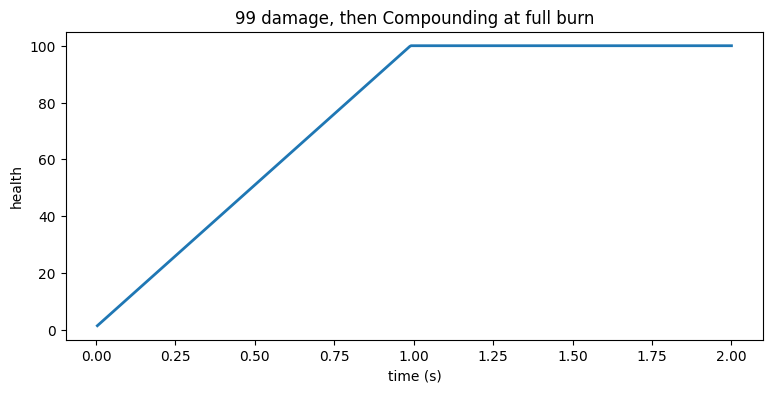

THE LEDGER
  misery prepaid into the goldmind: 20.0 HP
  healing delivered:                99.0 HP
  charge actually spent:            9.9 points (10x return)
  charge still banked:              10.1 points
  (Wayne, zero-sum, would have healed 20 HP and emptied the bank)


In [2]:
world = World()
health, goldmind, compounder = fresh_miles(world, charge_bank=20, metal_grams=10)
health.damage(99)
compounder.active = True
times, hp = run_sampling(world, 2.0, lambda: health.current)

figure, ax = plt.subplots(figsize=(9, 4))
ax.plot(times, hp, linewidth=2)
ax.set_xlabel("time (s)"); ax.set_ylabel("health")
ax.set_title("99 damage, then Compounding at full burn")
plt.show()

charge_spent = 20 - goldmind.reserve_health_points
print("THE LEDGER")
print(f"  misery prepaid into the goldmind: 20.0 HP")
print(f"  healing delivered:                {hp[-1] - 1:.1f} HP")
print(f"  charge actually spent:            {charge_spent:.1f} points (10x return)")
print(f"  charge still banked:              {goldmind.reserve_health_points:.1f} points")
print(f"  (Wayne, zero-sum, would have healed 20 HP and emptied the bank)")

## Experiment B — Hundredlives has a budget

Sustained 30 HP/s damage — *six times* the poison that killed Wayne in
notebook 04. Miles stores 3 HP/s the whole time (charge income exactly
matching the 3 charge/s his healing spends — a sustainable loop) and carries
10 g of gold. Prediction on paper: metal burns at 0.15 g/s, so the flatline
ends at ~67 s, and then he has about three seconds of being mortal.

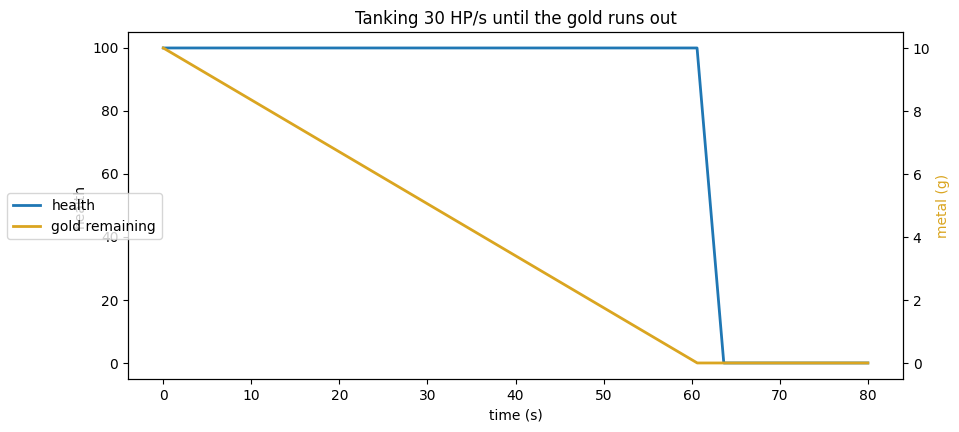

metal exhausted at 60.6 s; dead at 63.6 s


In [3]:
world = World()
health, goldmind, compounder = fresh_miles(world, charge_bank=50, metal_grams=10)
world.add_power(Poison(health, damage_per_second=30))
goldmind.store(3.0)
compounder.active = True
times, samples = run_sampling(world, 80.0,
                              lambda: (health.current, compounder.metal_supply_grams))
hp, metal = samples[:, 0], samples[:, 1]

figure, ax_hp = plt.subplots(figsize=(10, 4.5))
ax_hp.plot(times, hp, linewidth=2, label="health")
ax_hp.set_xlabel("time (s)"); ax_hp.set_ylabel("health")
ax_metal = ax_hp.twinx()
ax_metal.plot(times, metal, color="goldenrod", linewidth=2, label="gold remaining")
ax_metal.set_ylabel("metal (g)", color="goldenrod")
ax_hp.set_title("Tanking 30 HP/s until the gold runs out")
figure.legend(loc="center left")
plt.show()

death = times[np.argmax(hp <= 0)] if (hp <= 0).any() else None
metal_gone = times[np.argmax(metal <= 0)]
print(f"metal exhausted at {metal_gone:.1f} s; dead at {death:.1f} s")

## Experiment C — the breaking point, swept

One knob: incoming damage rate, 10 to 130 HP/s, everything else fixed (5 g of
gold, 50 charge banked, storing 3 HP/s). Two failure modes should appear:

- **Metal-limited** (low damage): he survives until the gold burns away —
  survival should fall like 1/damage.
- **Throughput-limited** (high damage): his healing ceiling is 100 HP/s
  (max burn x 10), so past that he dies with gold still in his pocket.

Coarser tick (1/60 s) for the sweep; HP rates don't need 240 Hz.

damage  10 HP/s -> survives   84.6 s
damage  20 HP/s -> survives   47.8 s
damage  30 HP/s -> survives   33.3 s
damage  40 HP/s -> survives   25.6 s
damage  50 HP/s -> survives   20.8 s
damage  60 HP/s -> survives   17.5 s
damage  70 HP/s -> survives   14.0 s
damage  80 HP/s -> survives   11.3 s
damage  90 HP/s -> survives    9.5 s
damage 100 HP/s -> survives    8.2 s
damage 110 HP/s -> survives    7.2 s
damage 120 HP/s -> survives    4.3 s
damage 130 HP/s -> survives    3.0 s


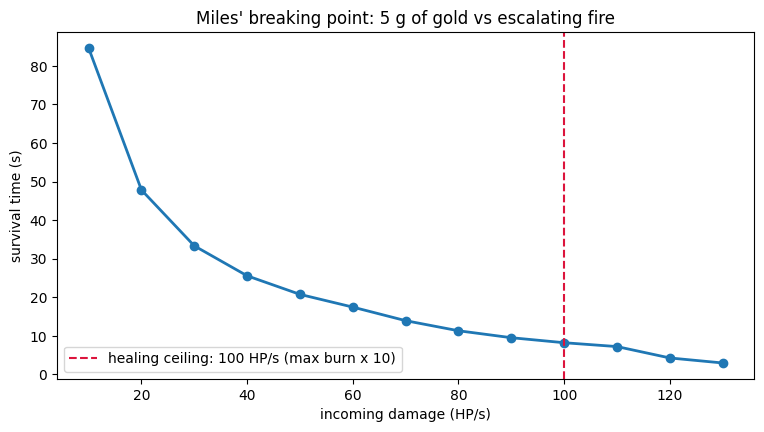

In [4]:
damage_rates = np.arange(10, 131, 10)
survival_times = []
for damage_rate in damage_rates:
    world = World(dt_seconds=1.0 / 60.0)
    health, goldmind, compounder = fresh_miles(world, charge_bank=50, metal_grams=5)
    world.add_power(Poison(health, damage_per_second=damage_rate))
    goldmind.store(3.0)
    compounder.active = True
    while not health.is_dead and world.time_seconds < 150:
        world.step()
    survival_times.append(world.time_seconds)
    print(f"damage {damage_rate:3d} HP/s -> survives {world.time_seconds:6.1f} s"
          + ("  (still alive at cutoff)" if not health.is_dead else ""))

figure, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(damage_rates, survival_times, "o-", linewidth=2)
ax.axvline(100, color="crimson", linestyle="--",
           label="healing ceiling: 100 HP/s (max burn x 10)")
ax.set_xlabel("incoming damage (HP/s)")
ax.set_ylabel("survival time (s)")
ax.set_title("Miles' breaking point: 5 g of gold vs escalating fire")
ax.legend()
plt.show()

## Findings

1. **The exploit is exactly as advertised**: 99 HP healed for 9.9 charge —
   a 10x return on prepaid misery that Wayne's lawful gold can never match.
   Zero-sum broke on screen, by precisely the canon factor.
2. **"Functionally unkillable" is a budget line, not a property.** Six times
   Wayne's lethal poison produced a flat line at full health — until the gold
   ran out, and Hundredlives died in about three seconds like anybody. The
   books' answer (you don't out-damage Miles, you exhaust or bypass him) is
   now a measured curve.
3. **Canon caveat on the sweep** (flagged by Elliott): the 100 HP/s healing
   ceiling is OUR knob (`max_burn_charge_per_second`), not lore. The books
   show Miles recovering from monstrous damage and dying exactly once — by
   firing squad, *after* his metalminds were stripped. Canon Miles has one
   budget: gold. The throughput-limited regime above is therefore a model
   artifact; to play canon-Miles, crank the max burn high enough that only
   the metal-limited regime exists.
4. **The original question is now answerable.** The idea doc asked: is Miles
   OP, does it match the books? Yes, and yes — quantifiably. The lab now
   holds all three originally-requested fighters: Wax (steel + ironmind),
   Wayne (goldmind + bendalloy), Miles (gold Compounding). Direction set by
   Elliott: **more metals next, not fighting.**